In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import os, sys

sys.path.insert(0, os.path.abspath('..'))

from src.constants import N_COMPONENTS, REDUCTION_METHOD, ASSET_COLS, COLOR_EXP as COLOR_0, COLOR_REC as COLOR_1, SHADE_COL, SHADE_A, LW
from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import prepare_macro_data, apply_dim_reduction, loading_table, train_test_split
from src.msvar_model import MSVARRegimeModel
from src.portfolio import (estimate_regime_moments, shrinkage_diagnostics,
                            optimize_regimes)
from src.plots import (plot_regime_states, plot_regime_probs, plot_regime_nber)


## Description

This notebook implements regime detection using **MSMH-VAR(K=2, p=1)** — a Markov-Switching Mean-Heteroskedastic Vector Autoregression.  Conditional on state k, macro indicators follow a VAR(1) process rather than being i.i.d. draws as in the Gaussian HMM.

The estimation pipeline is:
- **E-step**: Hamilton filter (forward pass) + Kim smoother (backward pass)
- **M-step**: Weighted OLS for VAR coefficients and covariances; MLE for the transition matrix

The MSVAR captures autoregressive macro dynamics that the HMM misses, and tends to produce more stable, less noisy regime classifications.

## Data preparation

Robust-scale macro indicators, apply PCA, and winsorize extreme scores.
VAR(p=1) consumes the first observation as a lag, so the effective sample size is T - 1 and regime labels align to `dates_train[1:]`.

In [2]:
macro_df = load_macro_data("../data/macro_clean.csv")
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,continuing_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply,dollar_index
Date,,,,,,,,,,,,,,,
1990-02-28,0.766740,0.213257,-0.176815,0.086523,0.140235,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.971936,-0.116878,0.017130
1990-03-31,0.370899,-0.142952,-0.176815,-0.056857,0.082572,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.385261,-0.207448,1.046560
1990-04-30,-0.367268,0.582737,0.366229,0.272514,0.167186,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.409511,-0.174649,-0.009542
1990-05-31,0.183034,-0.438133,0.004200,-0.054564,0.122786,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.370488,-0.904505,-0.734113
1990-06-30,0.216958,-0.097920,-0.357829,0.083436,0.050709,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.370905,-0.083910,-0.013835


In [3]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   continuing_claims       431 non-null    float64
 5   cpi                     431 non-null    float64
 6   oil_price               431 non-null    float64
 7   vix                     431 non-null    float64
 8   credit_spread           431 non-null    float64
 9   yield_curve_slope       431 non-null    float64
 10  fed_funds_rate          431 non-null    float64
 11  consumer_sentiment      431 non-null    float64
 12  housing_starts          431 non-null    float64
 13  m2_money_supply         431 non-null    float64
 14  dollar_index            431 non-nu


── PCA summary ──
  Input dimensions  : 15
  Components kept   : 5  (threshold = 85%)
  Variance explained: 82.1%

  Per-component breakdown:
    PC1: 44.9%  cumulative 44.9%  █████████████████
    PC2: 22.0%  cumulative 66.9%  ████████
    PC3:  6.4%  cumulative 73.3%  ██
    PC4:  5.1%  cumulative 78.4%  ██
    PC5:  3.7%  cumulative 82.1%  █

  Projected train shape : (431, 5)


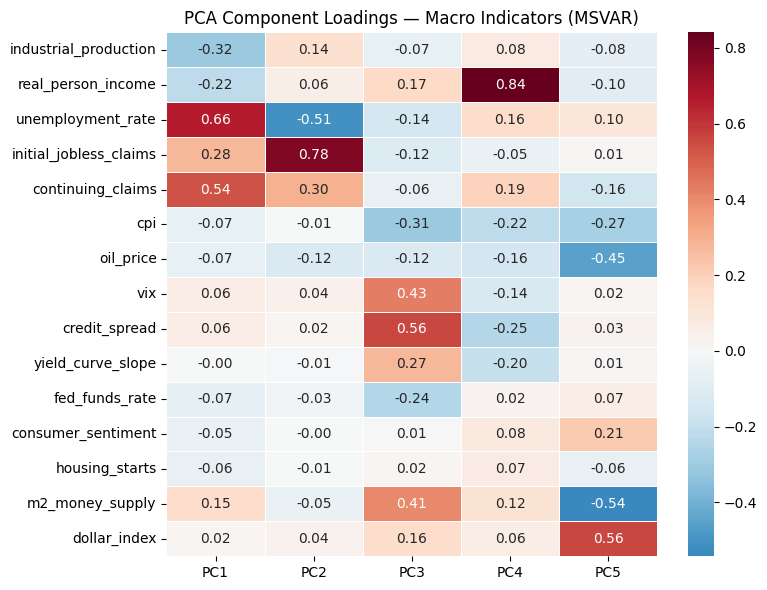

,PC1,PC2,PC3,PC4,PC5
industrial_production,-0.315169,0.136588,-0.069248,0.075304,-0.082776
real_person_income,-0.215720,0.055688,0.167748,0.841148,-0.097194
unemployment_rate,0.658866,-0.507020,-0.143152,0.159169,0.101060
initial_jobless_claims,0.283134,0.780911,-0.115395,-0.052534,0.011924
continuing_claims,0.535383,0.298170,-0.057772,0.194646,-0.158969
cpi,-0.068211,-0.006901,-0.306884,-0.222067,-0.274867
oil_price,-0.070292,-0.120084,-0.123049,-0.156983,-0.453607
vix,0.063464,0.044684,0.427994,-0.135428,0.017409
credit_spread,0.063300,0.017236,0.559525,-0.245439,0.026473
yield_curve_slope,-0.002262,-0.011050,0.274523,-0.195525,0.010903


In [4]:
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)

# Fitted on training data, clips applied
X_train_reduced, X_test_reduced, reducer = apply_dim_reduction(X_train, X_test,
                                          n_components=N_COMPONENTS, 
                                          method=REDUCTION_METHOD)


# loadings heatmap
loadings = loading_table(reducer, macro_df.columns.tolist())
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5)
plt.title('PCA Component Loadings — Macro Indicators (MSVAR)')
plt.tight_layout()
plt.savefig(f'../outputs/figures/{REDUCTION_METHOD}_loadings_msvar.png', dpi=150,
            bbox_inches='tight')
plt.show()
display(loadings)


In [5]:
print('Raw scaled  :', X_train.shape, X_test.shape if X_test is not None else None)
print('PCA reduced :', X_train_reduced.shape, X_test_reduced.shape if X_test_reduced is not None else None)


Raw scaled  : (431, 15) None
PCA reduced : (431, 5) None


## Model fitting

Fit MSMH-VAR(K=2, p=1) via EM with multiple random restarts.  The best restart (highest log-likelihood) is retained.  State ordering is enforced automatically: state 0 = expansion, state 1 = recession.

In [6]:
# Feed PCA-projected winsorized data to the MSVAR.
# Regime labels (integers indexed by date) are attached back to
# macro_df_expanded after fitting — all visualization cells unchanged.
model = MSVARRegimeModel(
    n_states=2, p=1, n_restarts=5, max_iter=300,
    tol=1e-6, random_state=42, verbose=True
)
model.fit(X_train_reduced)



--- Restart 1/5 ---
  iter    0 | log-lik = -988.815739 | Δ = inf
  iter   10 | log-lik = -680.765482 | Δ = 5.39e-01
  iter   20 | log-lik = -680.171158 | Δ = 9.73e-04
  iter   30 | log-lik = -680.170406 | Δ = 1.23e-06
  Converged at iteration 31.

--- Restart 2/5 ---
  iter    0 | log-lik = -1062.956353 | Δ = inf
  iter   10 | log-lik = -799.455476 | Δ = 1.01e+01
  iter   20 | log-lik = -656.595288 | Δ = 1.24e-01
  iter   30 | log-lik = -621.834197 | Δ = 1.55e-02
  iter   40 | log-lik = -621.679788 | Δ = 1.87e-04
  iter   50 | log-lik = -621.679751 | Δ = -1.01e-06
  Converged at iteration 51.

--- Restart 3/5 ---


c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msvar.py:418: UserWarning: Restart 1: log-lik decreased by -1.94e-06 at iter 43. Possible numerical issue.
  warnings.warn(f"Restart {restart}: log-lik decreased by {delta:.2e} at iter {iteration}. "
c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msvar.py:418: UserWarning: Restart 1: log-lik decreased by -4.64e-06 at iter 44. Possible numerical issue.
  warnings.warn(f"Restart {restart}: log-lik decreased by {delta:.2e} at iter {iteration}. "
c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msvar.py:418: UserWarning: Restart 1: log-lik decreased by -4.56e-06 at iter 45. Possible numerical issue.
  warnings.warn(f"Restart {restart}: log-lik decreased by {delta:.2e} at iter {iteration}. "
c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msva

  iter    0 | log-lik = -1027.016575 | Δ = inf
  iter   10 | log-lik = -827.899766 | Δ = 5.15e+00
  iter   20 | log-lik = -700.222045 | Δ = 3.85e+00
  iter   30 | log-lik = -621.929757 | Δ = 1.66e-01
  iter   40 | log-lik = -621.688198 | Δ = 1.41e-02
  iter   50 | log-lik = -621.679744 | Δ = -3.58e-06


c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msvar.py:418: UserWarning: Restart 2: log-lik decreased by -2.68e-06 at iter 47. Possible numerical issue.
  warnings.warn(f"Restart {restart}: log-lik decreased by {delta:.2e} at iter {iteration}. "
c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msvar.py:418: UserWarning: Restart 2: log-lik decreased by -4.73e-06 at iter 48. Possible numerical issue.
  warnings.warn(f"Restart {restart}: log-lik decreased by {delta:.2e} at iter {iteration}. "
c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msvar.py:418: UserWarning: Restart 2: log-lik decreased by -4.45e-06 at iter 49. Possible numerical issue.
  warnings.warn(f"Restart {restart}: log-lik decreased by {delta:.2e} at iter {iteration}. "
c:\Users\mydam\OneDrive\Desktop\WQU\Capstone\Capstone-improvement\regime-based-asset-allocator\src\msva

  Converged at iteration 54.

--- Restart 4/5 ---
  iter    0 | log-lik = -995.808145 | Δ = inf
  iter   10 | log-lik = -540.488618 | Δ = 1.87e-01
  iter   20 | log-lik = -540.409198 | Δ = 1.94e-04
  iter   30 | log-lik = -540.408898 | Δ = 2.53e-06
  Converged at iteration 33.

--- Restart 5/5 ---
  iter    0 | log-lik = -1094.669191 | Δ = inf
  iter   10 | log-lik = -831.814048 | Δ = 3.47e-01
  iter   20 | log-lik = -830.982409 | Δ = 1.16e-02
  iter   30 | log-lik = -830.650873 | Δ = 9.58e-02
  iter   40 | log-lik = -680.475272 | Δ = 2.07e-01
  iter   50 | log-lik = -680.170463 | Δ = 6.97e-05
  Converged at iteration 57.
State 0 = Expansion  (PC1 intercept: -0.012)
State 1 = Recession  (PC1 intercept: -0.478)
Transition matrix:
[[0.9559 0.0441]
 [0.5717 0.4283]]
State durations (months): ['22.7', '1.7']


In [7]:
model.summary()

MSMH-VAR(2, 1)  |  n=5, T=430
Log-likelihood : -540.4089
AIC            : 1264.8178
BIC            : 1638.6860
# parameters   : 92
EM iterations  : 34

Transition Matrix P (row i -> col j):
[[0.9559 0.0441]
 [0.5717 0.4283]]

Expected Regime Durations (periods):
  Regime 0: 22.7
  Regime 1: 1.7

Effective Sample Sizes:
  Regime 0: 399.3 obs (92.9%)
  Regime 1: 30.7 obs (7.1%)

--- Regime 0 VAR Intercept (mu) ---
[-0.012186 -0.011995 -0.013701 -0.003748  0.020921]
--- Regime 0 Covariance Sigma ---
[[ 0.121771  0.014723 -0.018127 -0.010599 -0.002825]
 [ 0.014723  0.079017  0.003481  0.004232  0.004229]
 [-0.018127  0.003481  0.057975  0.022485  0.018047]
 [-0.010599  0.004232  0.022485  0.070249  0.016238]
 [-0.002825  0.004229  0.018047  0.016238  0.101516]]

--- Regime 1 VAR Intercept (mu) ---
[-0.47761  -0.093208  0.397743  0.384316 -0.381679]
--- Regime 1 Covariance Sigma ---
[[ 1.50302   0.961572 -0.397164 -0.339132  0.040254]
 [ 0.961572  0.947526 -0.088448 -0.007508 -0.052511]
 [-

## Extracting results

In [8]:
# State 0 = expansion, state 1 = recession — enforced by _sort_regimes().
# No manual label flip needed (unlike original notebook).
smoothed_probs_train = model.smoothed_probs()
print('Smoothed probs shape:', smoothed_probs_train.shape)
print('Sum to 1:', np.allclose(smoothed_probs_train.sum(axis=0), 1.0))


Smoothed probs shape: (2, 430)
Sum to 1: True


In [9]:
# Filtered probs use only information up to time t — correct for
# walk-forward / out-of-sample evaluation (no look-ahead bias).
filtered_probs_train = model.filtered_probs()
print('Filtered probs shape:', filtered_probs_train.shape)
print('Sum to 1:', np.allclose(filtered_probs_train.sum(axis=0), 1.0))


Filtered probs shape: (2, 430)
Sum to 1: True


In [10]:
states_sequence = model.predict(use_smoothed=True)
print('State counts:', np.unique(states_sequence, return_counts=True))


State counts: (array([0, 1]), array([402,  28]))


In [11]:
# VAR(p=1) drops the first observation as a lag — align to dates_train[1:]
dates_msvar = dates_train[model.p:]
states_sequence_series = pd.Series(
    states_sequence, index=dates_msvar, name='MSVAR State'
)
states_sequence_series.value_counts()


MSVAR State
0    402
1     28
Name: count, dtype: int64

### Transition matrix

In [12]:
pd.DataFrame(
    model.transmat_,
    columns=[f'State {i}' for i in range(model.n_components)],
    index=[f'State {i}'   for i in range(model.n_components)]
)


,State 0,State 1
State 0,0.955943,0.044057
State 1,0.571691,0.428309


In [13]:
print('Average duration in each state (expected consecutive months):')
for i, d in enumerate(model.expected_durations):
    label = 'Expansion' if i == 0 else 'Recession'
    print(f'  State {i} ({label}): {d:.2f} months')


Average duration in each state (expected consecutive months):
  State 0 (Expansion): 22.70 months
  State 1 (Recession): 1.75 months


### Conditional means and covariance matrices

After PCA, `model.means_` has shape (K, n_components) representing the VAR intercept vector per regime in PC space.  Cross-reference with the loadings table above to interpret in original variable space.

In [14]:
if hasattr(reducer, 'n_components_'):   # PCA
    n_comp = reducer.n_components_
    component_names = [f'PC{j+1}'  for j in range(n_comp)]
else:                                    # PLS
    n_comp = reducer.n_components
    component_names = [f'PLS{j+1}' for j in range(n_comp)]

pd.DataFrame(
    model.means_,
    columns=component_names,
    index=['State 0', 'State 1']
).T


,State 0,State 1
PC1,-0.012186,-0.477610
PC2,-0.011995,-0.093208
PC3,-0.013701,0.397743
PC4,-0.003748,0.384316
PC5,0.020921,-0.381679


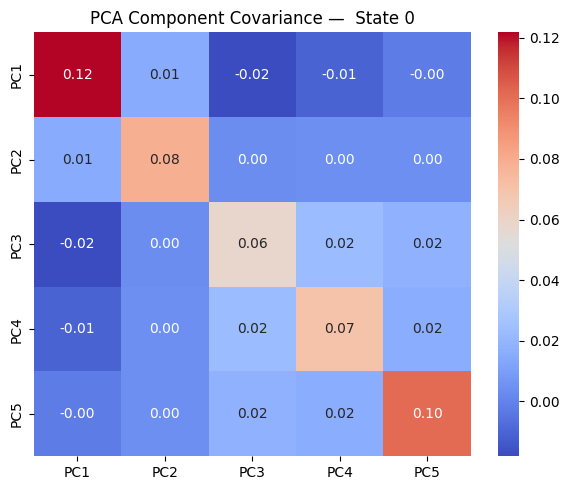

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[0], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('PCA Component Covariance —  State 0')
plt.tight_layout()
plt.show()


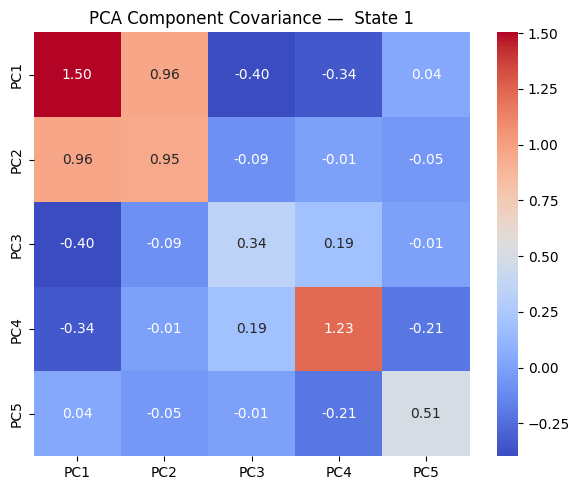

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[1], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('PCA Component Covariance —  State 1')
plt.tight_layout()
plt.show()


## Plotting results

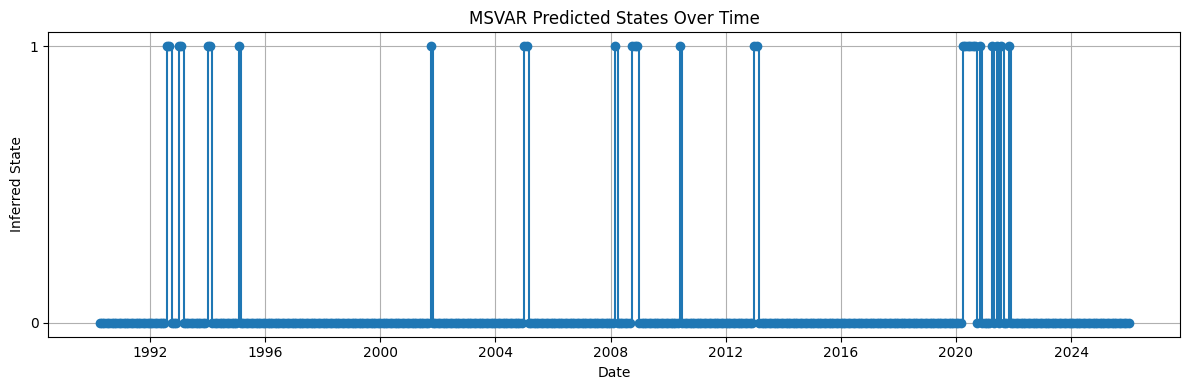

In [18]:
plot_regime_states(dates_msvar, states_sequence,
                   title='MSVAR Predicted States Over Time')
plt.show()


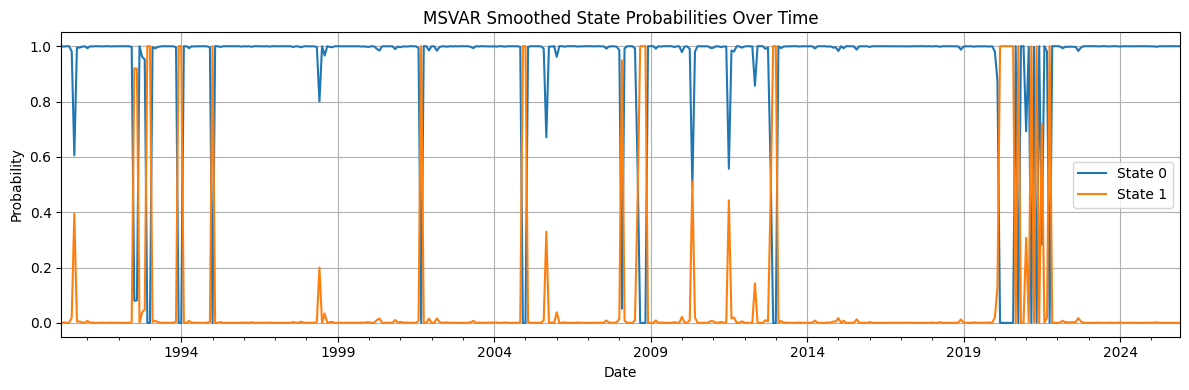

In [19]:
plot_regime_probs(dates_msvar, smoothed_probs_train,
                  title='MSVAR Smoothed State Probabilities Over Time')
plt.show()


In [20]:
# Attach regime labels to the original macro_df (original variable names).
# All downstream visualization cells use original series — PCA is invisible.
macro_df_expanded = macro_df.loc[dates_msvar].copy()
macro_df_expanded['MSVAR State'] = states_sequence


In [21]:
asset_df = load_asset_data('../data/market_clean.csv')
asset_df.columns = ['Equity', 'Bonds', 'Gold']
asset_df_expanded = asset_df.loc[dates_msvar].copy()
asset_df_expanded['MSVAR State'] = macro_df_expanded['MSVAR State']


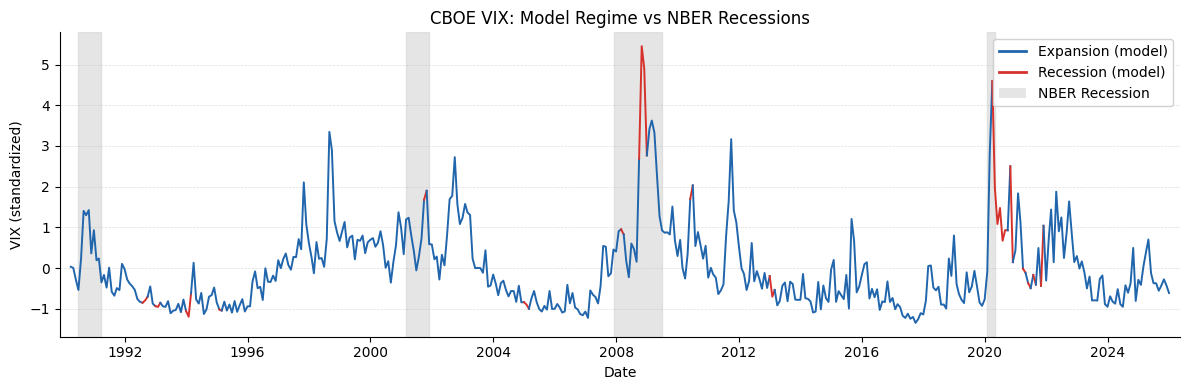

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='vix', state_col='MSVAR State',
    recession_state=1,
    title='CBOE VIX: Model Regime vs NBER Recessions',
    ylabel='VIX (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

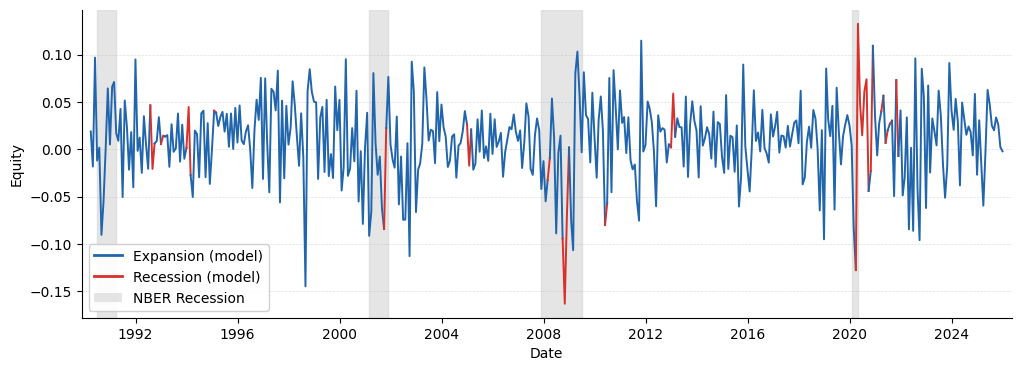

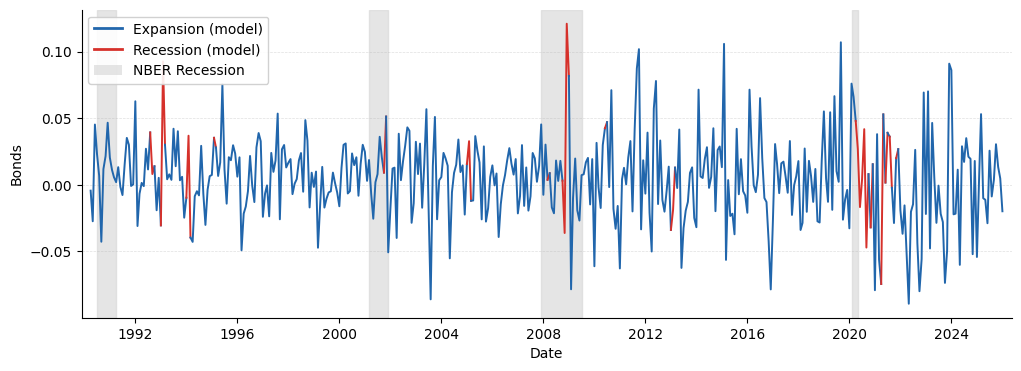

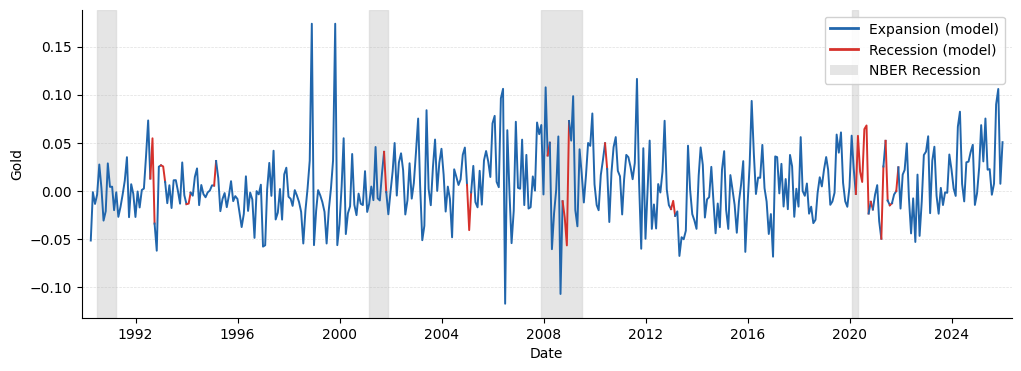

In [23]:
for col in asset_df.columns:
    plot_regime_nber(asset_df_expanded, series_name=col,
                       state_col='MSVAR State', recession_state=1)
    plt.show()


## Portfolio optimization

Regime-conditional MVO using Ledoit-Wolf covariance shrinkage and Bayes-Stein mean shrinkage, estimated on the training set.

In [24]:
market_train, market_test = train_test_split(asset_df_expanded)
print('Last train date:', market_train.index[-1])
print('First test date:', market_test.index[0])


Last train date: 2018-10-31 00:00:00
First test date: 2018-11-30 00:00:00


In [25]:
moments = estimate_regime_moments(
    market_train,
    asset_cols=market_train.columns[:-1].tolist(),
    state_col='MSVAR State'
)



── Regime 0  (327 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample +12.11%  →  BS +10.57%
    Bonds           : sample +6.78%  →  BS +7.45%
    Gold            : sample +4.82%  →  BS +4.81%
  Bayes-Stein φ  : 0.8976  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1861
  Implied annual volatilities (shrunk Σ):
    Equity          : 13.40%
    Bonds           : 10.20%
    Gold            : 12.62%

── Regime 1  (17 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample -22.77%  →  BS -9.12%
    Bonds           : sample +21.93%  →  BS +16.00%
    Gold            : sample +4.56%  →  BS +4.67%
  Bayes-Stein φ  : 0.4118  (mild shrinkage)
  Ledoit-Wolf α  : 0.9027
  Implied annual volatilities (shrunk Σ):
    Equity          : 16.27%
    Bonds           : 15.60%
    Gold            : 15.32%


In [26]:
shrinkage_diagnostics(moments, asset_cols=market_train.columns[:-1].tolist())



── Ledoit-Wolf shrinkage effect (shrunk Σ − raw Σ) ──

Regime 0  (α = 0.1861):
          Equity   Bonds    Gold
  Equity-0.00007 0.00002 0.00003
   Bonds 0.00002 0.00008-0.00003
    Gold 0.00003-0.00003-0.00003

Regime 1  (α = 0.9027):
          Equity   Bonds    Gold
  Equity-0.00154-0.00018-0.00012
   Bonds-0.00018 0.00022 0.00014
    Gold-0.00012 0.00014 0.00093


In [27]:
asset_names = market_train.columns[:-1]

print('=' * 55)
print('Regime-Conditional MVO')
print('=' * 55)
results = optimize_regimes(moments, asset_names, rf=0.0, long_only=True)


Regime-Conditional MVO

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +7.69%
  Volatility     (ann.) : 6.75%
  Sharpe ratio          : 1.1387
  Weights:
    Equity        : 0.3044  (30.4%)
    Bonds         : 0.4265  (42.6%)
    Gold          : 0.2692  (26.9%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +8.22%
  Volatility     (ann.) : 6.98%
  Sharpe ratio          : 1.1777
  Weights:
    Equity        : 0.3916  (39.2%)
    Bonds         : 0.4394  (43.9%)
    Gold          : 0.1691  (16.9%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +4.28%
  Volatility     (ann.) : 9.09%
  Sharpe ratio          : 0.4702
  Weights:
    Equity        : 0.3076  (30.8%)
    Bonds         : 0.3396  (34.0%)
    Gold          : 0.3528  (35.3%)

── max_sharpe  |  Regime 1 ──
  Expected return (ann.) : +13.32%
  Volatility     (ann.) : 12.43%
  Sharpe ratio          : 1.0722
  Weights:
    Equity        : 0.0000  (0.0%)
    Bonds         : 0.7640  (76.4%)
    Gold    

The recession regime has far fewer observations (~15-20 months vs ~150+ for expansion). Bayes-Stein shrinkage pulls the recession-regime mean toward the grand mean, making the MVO weights more conservative and less sensitive to noisy estimates.

### Target weights export

In [28]:
# ── Consolidated weight export: GMV and MVO ──────────────────────────
# Both exported for comparison in notebook 05.
# MVO weights come from results[k]['max_sharpe'] — already computed
# by optimize_regimes(); no need for a separate MeanVariancePortfolio call.
output_path = os.path.join('..', 'outputs/tables')
os.makedirs(output_path, exist_ok=True)

for label, obj in [('gmv', 'min_variance'), ('mvo', 'max_sharpe')]:
    weights_by_regime = {k: results[k][obj].weights for k in results}
    rows = []
    for date, regime in states_sequence_series.items():
        w = weights_by_regime[regime]
        rows.append({
            'Date':   date,
            'Regime': regime,
            'Equity': w[0],
            'Bonds':  w[1],
            'Gold':   w[2],
        })
    fname = f'msvar_{REDUCTION_METHOD}_{label}_target_weights.csv'
    pd.DataFrame(rows).to_csv(os.path.join(output_path, fname), index=False)
    print(f'Saved {fname}')
    display(pd.DataFrame(rows).head(3))


Saved msvar_pca_gmv_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-03-31,0,0.304372,0.426477,0.26915
1,1990-04-30,0,0.304372,0.426477,0.26915
2,1990-05-31,0,0.304372,0.426477,0.26915


Saved msvar_pca_mvo_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-03-31,0,0.391559,0.439377,0.169064
1,1990-04-30,0,0.391559,0.439377,0.169064
2,1990-05-31,0,0.391559,0.439377,0.169064


## Robustness Check: K = 3 Regimes

AIC and BIC are used for model comparison (LR test is non-standard under H0: K=2 per Garcia 1998).

In [29]:
# K=3 robustness check also uses PCA-projected data for consistency.
model_k3 = MSVARRegimeModel(
    n_states=3, p=1, n_restarts=3, max_iter=200,
    tol=1e-5, random_state=42, verbose=True
)
model_k3.fit(X_train_reduced)



--- Restart 1/3 ---
  iter    0 | log-lik = -964.528083 | Δ = inf
  iter   10 | log-lik = -483.457254 | Δ = 1.34e-01
  iter   20 | log-lik = -482.516697 | Δ = 1.37e-02
  iter   30 | log-lik = -482.444731 | Δ = 5.14e-03
  iter   40 | log-lik = -482.408741 | Δ = 1.85e-03
  iter   50 | log-lik = -482.401640 | Δ = 2.23e-04
  iter   60 | log-lik = -482.400823 | Δ = 2.63e-05
  Converged at iteration 65.

--- Restart 2/3 ---
  iter    0 | log-lik = -948.462214 | Δ = inf
  iter   10 | log-lik = -443.915077 | Δ = 2.68e-02
  iter   20 | log-lik = -443.828232 | Δ = 1.51e-03
  iter   30 | log-lik = -443.824175 | Δ = 7.88e-05
  Converged at iteration 39.

--- Restart 3/3 ---
  iter    0 | log-lik = -763.453768 | Δ = inf
  iter   10 | log-lik = -480.355998 | Δ = 1.43e-03
  iter   20 | log-lik = -480.352689 | Δ = 1.15e-04
  iter   30 | log-lik = -480.352129 | Δ = 2.81e-05
  Converged at iteration 39.
State 0 = Expansion  (PC1 intercept: -0.016)
State 1 = Recession  (PC1 intercept: -0.005)
State 2 = 

In [30]:
T = X_train_reduced.shape[0]
ll_k2      = model._result.log_likelihood
n_params_k2 = model._result.n_params
ll_k3      = model_k3._result.log_likelihood
n_params_k3 = model_k3._result.n_params

lr_stat  = 2 * (ll_k3 - ll_k2)
delta_df = n_params_k3 - n_params_k2

summary_k3 = pd.DataFrame({
    'K':               [2, 3],
    'Log-Likelihood':  [ll_k2, ll_k3],
    'N Parameters':    [n_params_k2, n_params_k3],
    'AIC': [-2*ll_k2 + 2*n_params_k2, -2*ll_k3 + 2*n_params_k3],
    'BIC': [-2*ll_k2 + n_params_k2*np.log(T),
            -2*ll_k3 + n_params_k3*np.log(T)],
})

print(f'LR statistic (K=2 vs K=3): {lr_stat:.2f}  (delta_df = {delta_df})')
print('Note: LR p-value non-standard under H0 — use AIC/BIC.')
display(summary_k3)


LR statistic (K=2 vs K=3): 193.17  (delta_df = 49)
Note: LR p-value non-standard under H0 — use AIC/BIC.


,K,Log-Likelihood,N Parameters,AIC,BIC
0,2,-540.408894,92,1264.817789,1638.899733
1,3,-443.823931,141,1169.647861,1742.969102


In [31]:
states_k3 = model_k3.predict(use_smoothed=True)
print('K=3 state counts:', dict(zip(*np.unique(states_k3, return_counts=True))))

# After PCA, B_list[k][:, 0] is the intercept in PC space.
# Display all components and cross-reference with loadings table.
means_k3 = pd.DataFrame(
    {f'State {k}': model_k3._result.B_list[k][:, 0]
     for k in range(model_k3.n_states)},
    index=component_names
)
print('\nK=3 regime intercepts (PC space):')
display(means_k3)



K=3 state counts: {np.int64(0): np.int64(372), np.int64(1): np.int64(48), np.int64(2): np.int64(10)}

K=3 regime intercepts (PC space):


,State 0,State 1,State 2
PC1,-0.016042,-0.005193,-1.295567
PC2,-0.016327,0.011191,-0.409350
PC3,-0.021305,0.057904,1.084011
PC4,0.001310,-0.122611,-0.022478
PC5,0.008812,-0.010522,-0.237278


In [32]:
summary_k3.to_csv(os.path.join(output_path, 'msvar_k3_model_selection.csv'),
                  index=False)
means_k3.to_csv(os.path.join(output_path, 'msvar_k3_regime_means.csv'))
print('Saved K=3 MSVAR results.')


Saved K=3 MSVAR results.
